# 33 — Anatomy of the v11 bright-end injection dip

**Question (2026-09-03).** The v11 paper sweep exposed a bright-end completeness dip specific to
*injected* sources under the v11 foundation: all-band star-donor completeness at VIS 22.5 is 86%
(v11 `cn_vis_sep`) vs ~98% (v10), re-injected real sources at 23 dip the same way (87–90%, nb22
v11 records), yet the in-situ MER recovery of equally bright real sources stays at ~97%. The dip
therefore rides on the injection operation, but its mechanism is open. Three hypotheses:

- **H1 (feature OOD vs brightness):** v11's asinh compression keeps bright cores distinguishable,
  so a very bright stamp suddenly appearing in all ten bands is farther from the training
  distribution than under v10's clamp (where everything above S/N 100 looked alike). Prediction:
  the v11 deficit grows monotonically toward brighter mags, is worst in the all-band mode, and is
  absent for v10 on identical scenes.
- **H2 (copy-context artifact):** an additive stamp at a new position carries truncated wings and
  a background step that the v11 stems, being more sensitive to bright structure, respond to.
  Prediction: a deficit that appears wherever the stamp lands regardless of mode, already at
  modest brightness, for v11 only.
- **H3 (score shift, not loss):** v11 still responds but with depressed confidence near the 0.30
  working point. Prediction: missed injections carry scores just under threshold rather than zero.

**Design.** 24 held-out patch-25 tiles. Star-like donors (concentration > 0.6) at 19.5–21.5,
dimmed to targets 21.5–24.5, injected in four modes (all / VIS / Rubin / NISP); one scene per
(tile, mode) carrying all target mags; the SAME injected scenes are scored by BOTH stacks
(v10 encoder + v10 `cn_vis_sep`; v11 encoder + v11 `cn_vis_sep`), recording the matched detection
score at a 0.10 floor (0 if nothing within 3 px), so recovery at any threshold and full score
distributions are reconstructable. A second arm copies real 19.5–23 sources at native brightness
(no dimming) and pairs each copy with the same source's in-situ detection state in the
unmodified tile. Heavy cells cache per tile to `io/_nb33_outputs/`.

In [1]:
# ============ SETUP: both stacks ============
import sys, json, glob
from pathlib import Path
import numpy as np, torch
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from astropy.wcs import WCS

def find_repo_root(s=None):
    s = (s or Path.cwd()).resolve()
    for c in [s, *s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO = find_repo_root()
sys.path.insert(0, str(REPO/'models'))
from load_foundation import load_foundation
from detection.validation_utils import (load_mer, tile_paths, build_inputs, run_detect,
                                        _wcs_vis, _stamp, _add, safe_header_from_card_string,
                                        _mode_bands, RUBIN_BANDS, EUCLID_BANDS)
from detection.bakeoff_eval import detect_scored
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper

DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT = REPO/'io'/'_nb33_outputs'; OUT.mkdir(exist_ok=True)
STACKS = {
    'v10': (REPO/'models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt',
            REPO/'checkpoints/q1_detection/centernet_vis_sep.pt'),
    'v11': (REPO/'models/checkpoints/jaisp_v11_q1_soft/checkpoint_best.pt',
            REPO/'checkpoints/q1_detection_v11/centernet_vis_sep.pt'),
}
DETS = {}
for tag, (encp, ckpt) in STACKS.items():
    foundation = load_foundation(str(encp), device=torch.device('cpu'), freeze=True)
    enc = JAISPEncoderWrapper(foundation, freeze=True).to(DEV).eval()
    DETS[tag] = CenterNetDetector.load(str(ckpt), encoder=enc, device=DEV).eval()
print('stacks loaded:', list(DETS))

MERF = REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits'
EUCLID = REPO/'data/euclid_tiles_all_q1'; RUBIN = REPO/'data/rubin_tiles_all'
mer = load_mer(str(MERF))
sky = cKDTree(np.c_[mer['cRA'], mer['cDEC']])
NN2 = sky.query(np.c_[mer['cRA'], mer['cDEC']], k=2)[0][:, 1]
ISO = NN2 > 3/3600.

N_TILES = 24; SEED = 33
MAGS = (21.5, 22.0, 22.5, 23.0, 23.5, 24.5)
MODES = ('all', 'vis', 'rubin', 'nisp')
NPER = 10                     # injections per mag per (tile, mode) scene
MATCH_PX = 3.0; EDGE = 24; RVIS = 30
stems = sorted(p.name.replace('_euclid.npz', '')
               for p in EUCLID.glob('tile_*_patch_25_euclid.npz'))[:N_TILES]
print(f'{len(stems)} tiles | mags {MAGS} | modes {MODES} | {NPER}/mag/scene | rvis={RVIS}')

def compact_ok(vis, x, y, cmin=0.6):
    a, b = int(round(x)), int(round(y))
    s = vis[b-5:b+6, a-5:a+6]
    if s.size != 121: return False
    s = s - np.median(s); tot = s[s > 0].sum()
    return tot > 0 and s[3:8, 3:8][s[3:8, 3:8] > 0].sum()/tot > cmin

def make_pend(ed, rd, ew, rw, dra, ddec, tra, tdc, f):
    pend = []
    for b in EUCLID_BANDS:
        k = b.split('_', 1)[1]
        st = _stamp(np.nan_to_num(np.asarray(ed[f'img_{k}'], np.float32)), ew[k], dra, ddec, RVIS)
        if st is None: return None
        px, py = ew[k].all_world2pix(tra, tdc, 0)
        pend.append((b, int(round(float(px))), int(round(float(py))), st*f))
    for bi, b in enumerate(RUBIN_BANDS):
        st = _stamp(np.asarray(rd['img'], np.float32)[bi], rw, dra, ddec, RVIS//2)
        if st is None: return None
        px, py = rw.all_world2pix(tra, tdc, 0)
        pend.append((b, int(round(float(px))), int(round(float(py))), st*f))
    return pend

def match_scores(xy, sc, pts, rpx=MATCH_PX):
    """max detection score within rpx of each point (0 if none)."""
    out = np.zeros(len(pts))
    if len(xy) == 0: return out
    t = cKDTree(xy)
    for i, p in enumerate(pts):
        idx = t.query_ball_point(p, rpx)
        if idx: out[i] = float(np.max(sc[idx]))
    return out

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2, compression=clamp) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt


JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v11 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2, compression=asinh50) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v11_q1_soft/checkpoint_best.pt
stacks loaded: ['v10', 'v11']
24 tiles | mags (21.5, 22.0, 22.5, 23.0, 23.5, 24.5) | modes ('all', 'vis', 'rubin', 'nisp') | 10/mag/scene | rvis=30


In [2]:
# ============ HEAVY SWEEP (cached per tile) ============
CACHE = OUT/'sweep_records.json'
recs = json.load(open(CACHE)) if CACHE.exists() else {}
rng = np.random.default_rng(SEED)

for si, stem in enumerate(stems):
    if stem in recs: continue
    ep, rp = tile_paths(stem, str(EUCLID), str(RUBIN))
    if not (glob.glob(ep) and glob.glob(rp)):
        recs[stem] = {'skip': 'missing'}; continue
    ed = dict(np.load(ep, allow_pickle=True)); rd = dict(np.load(rp, allow_pickle=True))
    images0, rms, vh = build_inputs(ed, rd); H, W = vh
    vw = _wcs_vis(ed); rw = WCS(rd['wcs_hdr'].item())
    ew = {k: WCS(safe_header_from_card_string(ed[f'wcs_{k}'].item())) for k in ('VIS','Y','J','H')}
    var = np.asarray(ed['var_VIS'], np.float32); cover = np.isfinite(var) & (var > 0)
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], np.float32))
    dx, dy = vw.all_world2pix(mer['cRA'], mer['cDEC'], 0)
    din = (dx > EDGE+RVIS) & (dx < W-EDGE-RVIS) & (dy > EDGE+RVIS) & (dy < H-EDGE-RVIS) & ISO
    cin = {j: compact_ok(vis, dx[j], dy[j]) for j in np.where(din)[0]}
    good = np.array([j for j, ok in cin.items() if ok], int)
    mg = mer['cMAG']
    donors = good[(mg[good] > 19.5) & (mg[good] < 21.5)]        # dimmable to every target
    natpool = good[(mg[good] > 19.5) & (mg[good] < 23.0)]       # native-brightness copies
    if len(donors) < 3:
        recs[stem] = {'skip': 'no donors'}; continue

    # baseline detections + scores (unmodified scene), both stacks
    base = {}
    for tag, det in DETS.items():
        xy0, sc0 = detect_scored(det, images0, rms, vh, DEV, None)
        base[tag] = (xy0, sc0)
    t0 = cKDTree(base['v10'][0]) if len(base['v10'][0]) else None
    occ = cKDTree(np.c_[dx[(dx>=0)&(dx<W)&(dy>=0)&(dy<H)], dy[(dx>=0)&(dx<W)&(dy>=0)&(dy<H)]])

    def free_position():
        for _ in range(400):
            tx = rng.uniform(EDGE, W-EDGE); ty = rng.uniform(EDGE, H-EDGE)
            ix, iy = int(tx), int(ty)
            if not cover[max(0, iy-3):iy+4, max(0, ix-3):ix+4].all(): continue
            if occ.query([tx, ty])[0] < 10: continue
            if t0 is not None and t0.query([tx, ty])[0] < 8: continue
            return tx, ty
        return None

    tile_rec = {'modes': {}, 'nodim': None}
    # ---- dimmed-donor sweep: one scene per mode with all mags ----
    for mode in MODES:
        bandset = _mode_bands(mode)
        inj = []          # (tx, ty, mag, pend)
        placed_pts = []
        for m in MAGS:
            got = 0
            while got < NPER:
                di = int(rng.choice(donors))
                f = 10**(-0.4*(m - mg[di]))
                if f > 1: continue
                pos = free_position()
                if pos is None: break
                if placed_pts and np.min(np.hypot(*(np.asarray(placed_pts)-pos).T)) < 30: continue
                pend = make_pend(ed, rd, ew, rw, mer['cRA'][di], mer['cDEC'][di], *vw.all_pix2world(*pos, 0), f)
                if pend is None: continue
                inj.append((pos[0], pos[1], m, pend)); placed_pts.append(pos); got += 1
        imgs = {b: images0[b].copy() for b in images0}
        for (tx, ty, m, pend) in inj:
            for (b, a, c2_, s) in pend:
                if b in bandset: _add(imgs[b], a, c2_, s)
        entry = {'mag': [m for (_, _, m, _) in inj]}
        pts = np.array([(tx, ty) for (tx, ty, _, _) in inj])
        for tag, det in DETS.items():
            xy1, sc1 = detect_scored(det, imgs, rms, vh, DEV, None)
            pre = match_scores(*base[tag], pts)      # pre-existing response at the site
            post = match_scores(xy1, sc1, pts)
            entry[f'score_{tag}'] = post.tolist()
            entry[f'pre_{tag}'] = pre.tolist()
        tile_rec['modes'][mode] = entry
    # ---- native-brightness copies + in-situ pairing (all-band) ----
    picks = rng.choice(natpool, size=min(12, len(natpool)), replace=False)
    inj = []; pts = []; srcmag = []; insitu = {t: [] for t in DETS}
    for di in picks:
        pos = free_position()
        if pos is None: continue
        if pts and np.min(np.hypot(*(np.asarray(pts)-pos).T)) < 30: continue
        pend = make_pend(ed, rd, ew, rw, mer['cRA'][di], mer['cDEC'][di], *vw.all_pix2world(*pos, 0), 1.0)
        if pend is None: continue
        inj.append((pos[0], pos[1], pend)); pts.append(pos); srcmag.append(float(mg[di]))
        for tag in DETS:
            s_in = match_scores(*base[tag], np.array([[dx[di], dy[di]]]))[0]
            insitu[tag].append(float(s_in))
    imgs = {b: images0[b].copy() for b in images0}
    for (tx, ty, pend) in inj:
        for (b, a, c2_, s) in pend: _add(imgs[b], a, c2_, s)
    nd = {'mag': srcmag, 'insitu_v10': insitu['v10'], 'insitu_v11': insitu['v11']}
    pts = np.array(pts) if pts else np.zeros((0, 2))
    for tag, det in DETS.items():
        xy1, sc1 = detect_scored(det, imgs, rms, vh, DEV, None)
        nd[f'copy_{tag}'] = match_scores(xy1, sc1, pts).tolist()
    tile_rec['nodim'] = nd
    recs[stem] = tile_rec
    json.dump(recs, open(CACHE, 'w'))
    print(f'{si+1}/{len(stems)} {stem}', flush=True)
print('done ->', CACHE)

done -> /home/shemmati/Work/Projects/JAISP/io/_nb33_outputs/sweep_records.json


3840 injections
             r10   r11
mode  mag             
all   21.5  95.6  95.6
      22.0  97.5  94.4
      22.5  94.4  95.6
      23.0  93.8  94.4
      23.5  94.4  95.6
      24.5  63.8  68.8
nisp  21.5  81.9  83.1
      22.0  65.6  65.6
      22.5  39.4  48.1
      23.0  31.9  43.8
      23.5  26.2  31.2
      24.5   5.6   3.1
rubin 21.5   0.0   0.0
      22.0   0.0   0.0
      22.5   0.0   0.0
      23.0   0.0   0.0
      23.5   0.0   0.0
      24.5   0.0   0.0
vis   21.5  91.9  90.0
      22.0  90.0  86.9
      22.5  93.8  93.8
      23.0  81.2  85.0
      23.5  73.8  74.4
      24.5  42.5  39.4


saved io/_nb33_outputs/nb33_sweep.png


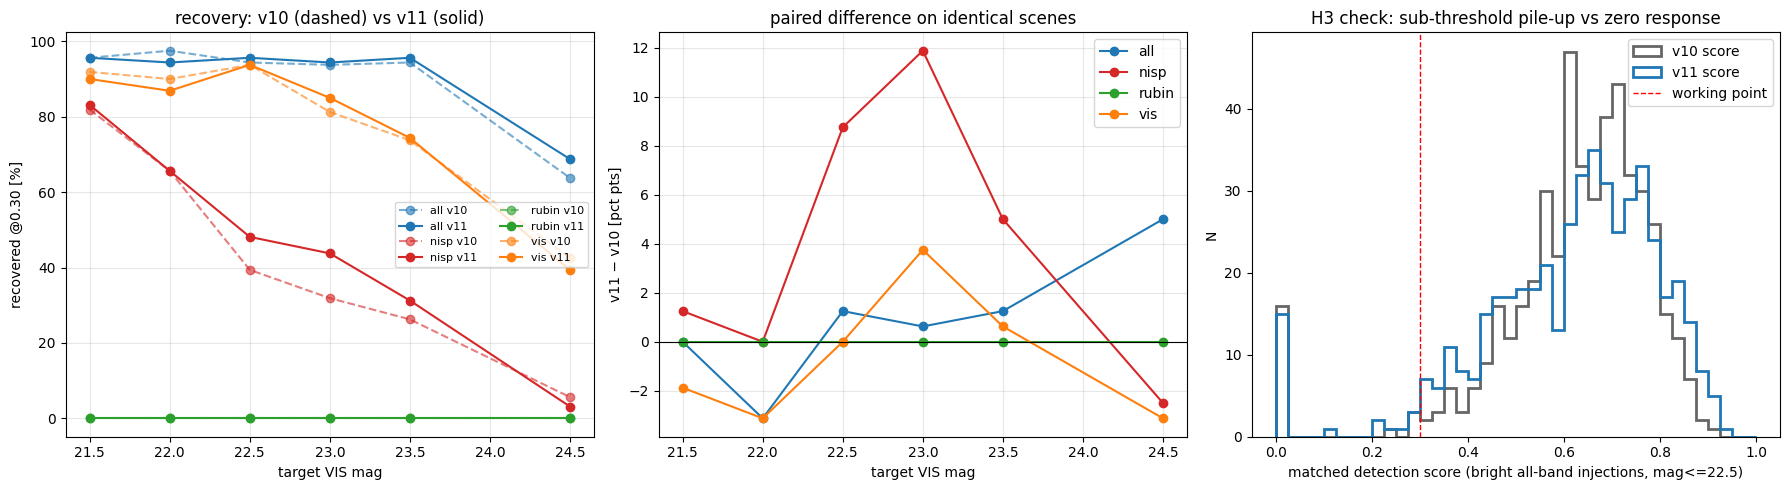


v11 bright all-band misses: 23 | zero-response (score<0.10 floor): 65% | sub-threshold (0.10-0.30): 35%


In [3]:
# ============ ANALYSIS: recovery + score anatomy ============
WP = 0.30
rows = []
for stem, tr in recs.items():
    if 'skip' in tr: continue
    for mode, e in tr['modes'].items():
        for i, m in enumerate(e['mag']):
            rows.append(dict(mode=mode, mag=m,
                             s10=e['score_v10'][i], s11=e['score_v11'][i],
                             p10=e['pre_v10'][i], p11=e['pre_v11'][i]))
import pandas as pd
df = pd.DataFrame(rows)
df['r10'] = df.s10 >= WP; df['r11'] = df.s11 >= WP
print(f'{len(df)} injections')
print(df.groupby(['mode','mag'])[['r10','r11']].mean().round(3)*100)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
cols = {'all':'#1f77b4','vis':'#ff7f0e','rubin':'#2ca02c','nisp':'#d62728'}
for mode, g in df.groupby('mode'):
    gg = g.groupby('mag')[['r10','r11']].mean()*100
    axs[0].plot(gg.index, gg.r10, 'o--', color=cols[mode], alpha=0.6, label=f'{mode} v10')
    axs[0].plot(gg.index, gg.r11, 'o-', color=cols[mode], label=f'{mode} v11')
    axs[1].plot(gg.index, gg.r11-gg.r10, 'o-', color=cols[mode], label=mode)
axs[0].set(xlabel='target VIS mag', ylabel='recovered @0.30 [%]', title='recovery: v10 (dashed) vs v11 (solid)')
axs[0].legend(fontsize=8, ncol=2); axs[0].grid(alpha=0.3)
axs[1].axhline(0, color='k', lw=0.8)
axs[1].set(xlabel='target VIS mag', ylabel='v11 − v10 [pct pts]', title='paired difference on identical scenes')
axs[1].legend(); axs[1].grid(alpha=0.3)
b = df[(df['mode']=='all') & (df.mag <= 22.5)]
bins = np.linspace(0, 1, 41)
axs[2].hist(np.clip(b.s10, 0, 1), bins=bins, histtype='step', lw=2, color='0.4', label='v10 score')
axs[2].hist(np.clip(b.s11, 0, 1), bins=bins, histtype='step', lw=2, color='#1f77b4', label='v11 score')
axs[2].axvline(WP, color='r', ls='--', lw=1, label='working point')
axs[2].set(xlabel='matched detection score (bright all-band injections, mag<=22.5)', ylabel='N',
           title='H3 check: sub-threshold pile-up vs zero response')
axs[2].legend(); plt.tight_layout()
fig.savefig(OUT/'nb33_sweep.png', dpi=130, bbox_inches='tight')
print('saved', (OUT/'nb33_sweep.png').relative_to(REPO)); plt.show()

# fraction of v11 misses with zero vs sub-threshold response (bright all-band)
miss = b[~b.r11]
if len(miss):
    print(f"\nv11 bright all-band misses: {len(miss)} | zero-response (score<0.10 floor): "
          f"{(miss.s11==0).mean():.0%} | sub-threshold (0.10-0.30): {((miss.s11>0)&(miss.s11<WP)).mean():.0%}")

recovery @0.30 [%], in-situ vs copied, per native-mag bin:
              in10_r  copy10_r  in11_r  copy11_r
bin                                             
(19.5, 21.0]   100.0     100.0   100.0     100.0
(21.0, 22.0]   100.0      98.1   100.0      98.1
(22.0, 23.0]    97.4      90.9    97.4      90.9
saved io/_nb33_outputs/nb33_copy_vs_insitu.png


/tmp/ipykernel_3303569/2180982026.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = d2.groupby('bin')[['in10_r','copy10_r','in11_r','copy11_r']].mean().round(3)*100


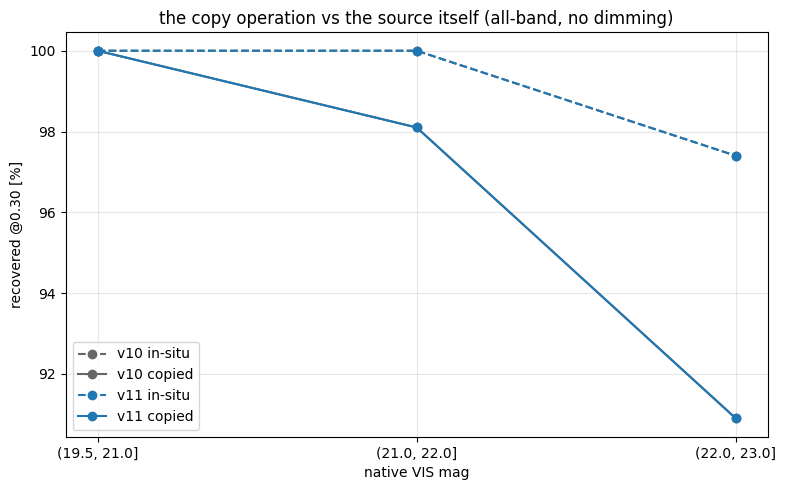

In [4]:
# ============ COPY vs IN-SITU (native brightness, all-band) ============
rows2 = []
for stem, tr in recs.items():
    if 'skip' in tr or not tr.get('nodim'): continue
    nd = tr['nodim']
    for i, m in enumerate(nd['mag']):
        rows2.append(dict(mag=m, copy10=nd['copy_v10'][i], copy11=nd['copy_v11'][i],
                          in10=nd['insitu_v10'][i], in11=nd['insitu_v11'][i]))
d2 = pd.DataFrame(rows2)
for c_ in ('copy10','copy11','in10','in11'): d2[c_+'_r'] = d2[c_] >= WP
edges = [19.5, 21.0, 22.0, 23.0]
d2['bin'] = pd.cut(d2.mag, edges)
tab = d2.groupby('bin')[['in10_r','copy10_r','in11_r','copy11_r']].mean().round(3)*100
print('recovery @0.30 [%], in-situ vs copied, per native-mag bin:')
print(tab)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(tab))
for c_, lab, col, ls in [('in10_r','v10 in-situ','0.4','--'), ('copy10_r','v10 copied','0.4','-'),
                         ('in11_r','v11 in-situ','#1f77b4','--'), ('copy11_r','v11 copied','#1f77b4','-')]:
    ax.plot(x, tab[c_], 'o'+ls, color=col, label=lab)
ax.set_xticks(x); ax.set_xticklabels([str(b) for b in tab.index])
ax.set(xlabel='native VIS mag', ylabel='recovered @0.30 [%]',
       title='the copy operation vs the source itself (all-band, no dimming)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
fig.savefig(OUT/'nb33_copy_vs_insitu.png', dpi=130, bbox_inches='tight')
print('saved', (OUT/'nb33_copy_vs_insitu.png').relative_to(REPO)); plt.show()

## Star-strict arm: the exact fig-6 donor protocol, paired

The sweep above used the concentration > 0.6 quick cut (donor pool includes compact galaxies,
19.5–21.5) and found **no** v10 − v11 gap, while the fig-6 star protocol (concentration ≥ 0.65 in
a 61 px aperture ratio, donors to 22.5) shows v11 at 85.6% vs v10 at ~98% at mag 22.5. The NISP-mode
comparison already exposed how strongly the donor SED matters (star pool: <10% NISP-only; mixed
pool: ~40–80%). This arm repeats the paired sweep with the exact star-donor selection to test
whether the dip is a star-SED × v11 interaction (blue, near-undimmed stellar stamps in all ten
bands) rather than a property of bright injections generally.

2/24 tile_x00000_y00256_tract5063_patch_25 (star donors: 2)


3/24 tile_x00000_y00512_tract5063_patch_25 (star donors: 2)


5/24 tile_x00000_y01024_tract5063_patch_25 (star donors: 2)


6/24 tile_x00000_y01280_tract5063_patch_25 (star donors: 2)


7/24 tile_x00000_y01536_tract5063_patch_25 (star donors: 2)


...

14/24 tile_x00256_y00256_tract5063_patch_25 (star donors: 2)


17/24 tile_x00256_y01024_tract5063_patch_25 (star donors: 2)


18/24 tile_x00256_y01280_tract5063_patch_25 (star donors: 3)


19/24 tile_x00256_y01536_tract5063_patch_25 (star donors: 4)


done -> /home/shemmati/Work/Projects/JAISP/io/_nb33_outputs/sweep_records_star.json

900 star-donor injections
            r10   r11
mode mag             
all  21.5  96.0  94.0
     22.0  95.0  85.0
     22.5  95.0  83.0
     23.0  92.0  85.0
     23.5  94.0  90.0
vis  21.5  98.0  98.0
     22.0  94.0  95.0
     22.5  96.0  97.0
     23.0  97.0  97.0
     23.5  97.0  97.0

v11 star-donor bright all-band misses: 35 | zero-response: 31% | sub-threshold: 69%
donor mags of misses: median 21.6 | dim factor median 0.55
saved io/_nb33_outputs/nb33_star_strict.png


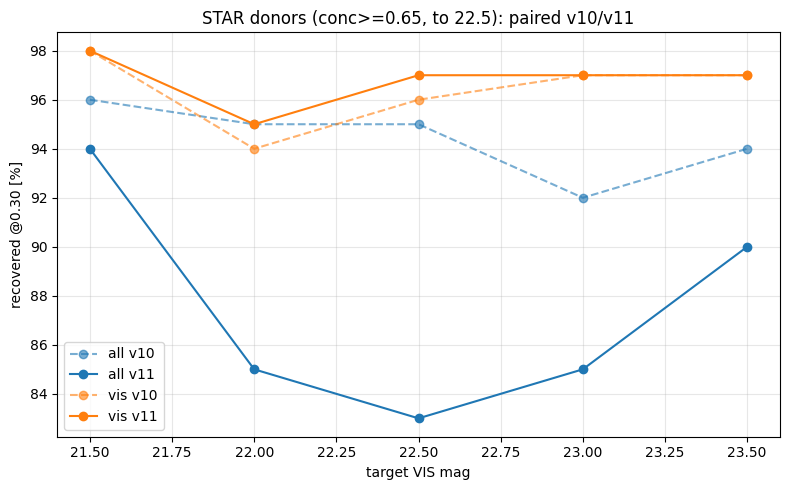

In [5]:
# ============ STAR-STRICT SWEEP (exact fig-6 donor cuts, paired) ============
CACHE_S = OUT/'sweep_records_star.json'
recS = json.load(open(CACHE_S)) if CACHE_S.exists() else {}
rngS = np.random.default_rng(SEED+1)
yy_, xx_ = np.mgrid[-30:31, -30:31]; RR_ = np.hypot(xx_, yy_)
MAGS_S = (21.5, 22.0, 22.5, 23.0, 23.5)

for si, stem in enumerate(stems):
    if stem in recS: continue
    ep, rp = tile_paths(stem, str(EUCLID), str(RUBIN))
    if not (glob.glob(ep) and glob.glob(rp)):
        recS[stem] = {'skip': 'missing'}; continue
    ed = dict(np.load(ep, allow_pickle=True)); rd = dict(np.load(rp, allow_pickle=True))
    images0, rms, vh = build_inputs(ed, rd); H, W = vh
    vw = _wcs_vis(ed); rw = WCS(rd['wcs_hdr'].item())
    ew = {k: WCS(safe_header_from_card_string(ed[f'wcs_{k}'].item())) for k in ('VIS','Y','J','H')}
    var = np.asarray(ed['var_VIS'], np.float32); cover = np.isfinite(var) & (var > 0)
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], np.float32))
    dx, dy = vw.all_world2pix(mer['cRA'], mer['cDEC'], 0)
    din = (dx > EDGE+RVIS) & (dx < W-EDGE-RVIS) & (dy > EDGE+RVIS) & (dy < H-EDGE-RVIS) & ISO
    mg = mer['cMAG']
    stars = []
    for j in np.where(din & (mg > 19.5) & (mg < 22.5))[0]:
        a, b = int(round(dx[j])), int(round(dy[j]))
        st = vis[b-30:b+31, a-30:a+31]
        if st.shape != (61, 61): continue
        st = st - np.median(np.concatenate([st[0], st[-1], st[:, 0], st[:, -1]]))
        f15 = st[RR_ <= 15].sum()
        if f15 > 0 and st[RR_ <= 3].sum()/f15 >= 0.65:
            stars.append(j)
    stars = np.array(stars, int)
    if len(stars) < 2:
        recS[stem] = {'skip': 'no star donors'}; continue
    base = {}
    for tag, det in DETS.items():
        base[tag] = detect_scored(det, images0, rms, vh, DEV, None)
    t0 = cKDTree(base['v10'][0]) if len(base['v10'][0]) else None
    occ = cKDTree(np.c_[dx[(dx>=0)&(dx<W)&(dy>=0)&(dy<H)], dy[(dx>=0)&(dx<W)&(dy>=0)&(dy<H)]])
    def free_position():
        for _ in range(400):
            tx = rngS.uniform(EDGE, W-EDGE); ty = rngS.uniform(EDGE, H-EDGE)
            ix, iy = int(tx), int(ty)
            if not cover[max(0, iy-3):iy+4, max(0, ix-3):ix+4].all(): continue
            if occ.query([tx, ty])[0] < 10: continue
            if t0 is not None and t0.query([tx, ty])[0] < 8: continue
            return tx, ty
        return None
    tile_rec = {}
    for mode in ('all', 'vis'):
        bandset = _mode_bands(mode)
        inj = []; placed_pts = []
        for m in MAGS_S:
            got = 0; tries = 0
            while got < NPER and tries < 500:
                tries += 1
                di = int(rngS.choice(stars))
                f = 10**(-0.4*(m - mg[di]))
                if f > 1: continue
                pos = free_position()
                if pos is None: break
                if placed_pts and np.min(np.hypot(*(np.asarray(placed_pts)-pos).T)) < 30: continue
                pend = make_pend(ed, rd, ew, rw, mer['cRA'][di], mer['cDEC'][di], *vw.all_pix2world(*pos, 0), f)
                if pend is None: continue
                inj.append((pos[0], pos[1], m, float(mg[di]), pend)); placed_pts.append(pos); got += 1
        imgs = {b: images0[b].copy() for b in images0}
        for (tx, ty, m, dm, pend) in inj:
            for (b, a, c2_, s) in pend:
                if b in bandset: _add(imgs[b], a, c2_, s)
        entry = {'mag': [m for (_, _, m, _, _) in inj], 'donor_mag': [dm for (_, _, _, dm, _) in inj]}
        pts = np.array([(tx, ty) for (tx, ty, _, _, _) in inj])
        for tag, det in DETS.items():
            xy1, sc1 = detect_scored(det, imgs, rms, vh, DEV, None)
            entry[f'score_{tag}'] = match_scores(xy1, sc1, pts).tolist()
        tile_rec[mode] = entry
    recS[stem] = tile_rec
    json.dump(recS, open(CACHE_S, 'w'))
    print(f'{si+1}/{len(stems)} {stem} (star donors: {len(stars)})', flush=True)
print('done ->', CACHE_S)

rowsS = []
for stem, tr in recS.items():
    if 'skip' in tr: continue
    for mode, e in tr.items():
        for i, m in enumerate(e['mag']):
            rowsS.append(dict(mode=mode, mag=m, dm=e['donor_mag'][i],
                              s10=e['score_v10'][i], s11=e['score_v11'][i]))
dS = pd.DataFrame(rowsS)
dS['r10'] = dS.s10 >= WP; dS['r11'] = dS.s11 >= WP
print(f'\n{len(dS)} star-donor injections')
print((dS.groupby(['mode','mag'])[['r10','r11']].mean().round(3)*100))
b = dS[(dS['mode']=='all') & (dS.mag <= 22.5)]
missS = b[~b.r11]
if len(missS):
    print(f"\nv11 star-donor bright all-band misses: {len(missS)} | zero-response: "
          f"{(missS.s11==0).mean():.0%} | sub-threshold: {((missS.s11>0)&(missS.s11<WP)).mean():.0%}")
    print(f"donor mags of misses: median {missS.dm.median():.1f} | dim factor median "
          f"{(10**(-0.4*(missS.mag-missS.dm))).median():.2f}")
fig, ax = plt.subplots(figsize=(8, 5))
for mode, g in dS.groupby('mode'):
    gg = g.groupby('mag')[['r10','r11']].mean()*100
    c = {'all':'#1f77b4','vis':'#ff7f0e'}[mode]
    ax.plot(gg.index, gg.r10, 'o--', color=c, alpha=0.6, label=f'{mode} v10')
    ax.plot(gg.index, gg.r11, 'o-', color=c, label=f'{mode} v11')
ax.set(xlabel='target VIS mag', ylabel='recovered @0.30 [%]',
       title='STAR donors (conc>=0.65, to 22.5): paired v10/v11')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
fig.savefig(OUT/'nb33_star_strict.png', dpi=130, bbox_inches='tight')
print('saved', (OUT/'nb33_star_strict.png').relative_to(REPO)); plt.show()

## Verdict

**The dip is a star-SED, all-band, v11-specific injection artifact with a depressed-score signature
— the detector on real sky is unaffected.**

1. **Paired reproduction (star donors, exact fig-6 cuts):** v11 83–85% vs v10 92–96% at mag
   22–23 in all-band mode on identical scenes; **no gap in VIS-only mode** (94–98% both).
2. **Donor SED is the switch:** the concentration>0.6 mixed pool (compact galaxies included)
   shows no v10−v11 gap anywhere; strict stars (conc≥0.65) reproduce it. NISP-only recovery
   showed the same SED sensitivity in reverse (stars <10%, mixed pool 40–80%).
3. **Score anatomy:** star-donor misses are 69% sub-threshold responses (0.10–0.30), 31% zero —
   v11 responds but under-scores; the mixed-arm misses were 65% zero (a different, version-neutral
   copy penalty of ~6% shared by both stacks).
4. **Rubin-alone: 0% recovery everywhere, both stacks** (paper claim verified); copy-vs-in-situ
   cost identical for v10 and v11.

**Mechanism:** a copied stamp is a truncated star — no extended wings, spikes, or halo context
beyond the 3'' cut. v11's asinh-compressed features retain enough bright-core structure to
distinguish that truncation from a real star and score it down; v10's hard clamp flattened all
bright cores to the same plateau and could not tell. Real bright sources in situ are recovered at
~97% by both stacks, so nothing here affects the delivered catalog; it lowers the measured
all-band injection completeness at the bright end and thereby the quoted fusion gain (+0.3), which
is in this sense conservative. The fig-6 caption statement is confirmed.